<a href="https://colab.research.google.com/github/Abeldb11/LLM_opt/blob/main/MOE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -q transformers datasets accelerate

In [1]:
import math
import time
import copy
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

MODEL_NAME = "gpt2"  # 124M params

Using device: cuda
Tesla T4


In [2]:
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

baseline_model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
baseline_model.eval()
print(baseline_model.config)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "use_cache": true,
  "vocab_size": 50257
}



In [15]:
from datasets import load_dataset

# Using the official salesforce/wikitext repository
dataset = load_dataset("salesforce/wikitext", "wikitext-2-raw-v1")

train_text = "\n\n".join([t for t in dataset["train"]["text"] if t.strip()])
val_text = "\n\n".join([t for t in dataset["validation"]["text"] if t.strip()])

print(f"Train chars: {len(train_text):,} | Val chars: {len(val_text):,}")

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Train chars: 10,940,522 | Val chars: 1,147,070


In [16]:
def tokenize_and_chunk(text, tokenizer, block_size=512):
    '''Tokenize a big blob of text and cut it into fixed-length blocks
    (dropping the remainder) so every training/eval batch has the same shape.'''
    ids = tokenizer(text, return_tensors="pt").input_ids[0]
    n_blocks = len(ids) // block_size
    ids = ids[: n_blocks * block_size]
    return ids.view(n_blocks, block_size)

BLOCK_SIZE = 512
train_blocks = tokenize_and_chunk(train_text, tokenizer, BLOCK_SIZE)
val_blocks = tokenize_and_chunk(val_text, tokenizer, BLOCK_SIZE)
print(f"Train blocks: {tuple(train_blocks.shape)}  Val blocks: {tuple(val_blocks.shape)}")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2415650 > 1024). Running this sequence through the model will result in indexing errors


Train blocks: (4718, 512)  Val blocks: (487, 512)


In [17]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


@torch.no_grad()
def evaluate_perplexity(model, blocks, device, batch_size=4, max_batches=60):
    '''Token-weighted perplexity over (a subset of) the validation blocks.'''
    model.eval()
    total_loss, total_tokens = 0.0, 0
    n_batches = min(max_batches, math.ceil(len(blocks) / batch_size))
    for b in range(n_batches):
        i = b * batch_size
        batch = blocks[i : i + batch_size].to(device)
        if batch.shape[0] == 0:
            break
        out = model(batch, labels=batch)
        n_tok = batch.numel()
        total_loss += out.loss.item() * n_tok
        total_tokens += n_tok
    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss), avg_loss


@torch.no_grad()
def measure_latency(model, tokenizer, device, prompt="The future of artificial intelligence is",
                     n_runs=10, max_new_tokens=50):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    for _ in range(3):  # warmup
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                            pad_token_id=tokenizer.eos_token_id)
    if device.type == "cuda":
        torch.cuda.synchronize()
    times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                            pad_token_id=tokenizer.eos_token_id)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.time() - start)
    avg_time = float(np.mean(times))
    return avg_time, max_new_tokens / avg_time


def model_size_mb(total_params, bytes_per_param=4):
    return total_params * bytes_per_param / 1e6


In [18]:
baseline_results = {}
baseline_results["total_params"], _ = count_parameters(baseline_model)
baseline_results["active_params"] = baseline_results["total_params"]  # dense: all params active
baseline_results["size_mb"] = model_size_mb(baseline_results["total_params"])
baseline_results["ppl"], baseline_results["loss"] = evaluate_perplexity(baseline_model, val_blocks, device)
baseline_results["latency_s"], baseline_results["tokens_per_sec"] = measure_latency(baseline_model, tokenizer, device)

print(json.dumps(baseline_results, indent=2))


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


{
  "total_params": 124439808,
  "active_params": 124439808,
  "size_mb": 497.759232,
  "ppl": 33.891014609417844,
  "loss": 3.5231499234835306,
  "latency_s": 0.46591179370880126,
  "tokens_per_sec": 107.31645061393405
}


In [19]:
class Expert(nn.Module):
    '''A single FFN expert — structurally identical to GPT-2's MLP block.'''

    def __init__(self, hidden_size, intermediate_size, activation_fn, dropout=0.1):
        super().__init__()
        self.fc_in = nn.Linear(hidden_size, intermediate_size)
        self.fc_out = nn.Linear(intermediate_size, hidden_size)
        self.act = activation_fn
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc_in(x)
        x = self.act(x)
        x = self.fc_out(x)
        return self.dropout(x)


class MoEMLP(nn.Module):
    '''Sparse Mixture-of-Experts replacement for GPT-2's dense MLP block.

    Each token is routed to its top-k experts (out of num_experts) by a learned
    router. Only the selected experts do work for that token.
    '''

    def __init__(self, hidden_size, intermediate_size, activation_fn,
                 num_experts=4, top_k=2, dropout=0.1):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.hidden_size = hidden_size

        self.experts = nn.ModuleList([
            Expert(hidden_size, intermediate_size, activation_fn, dropout)
            for _ in range(num_experts)
        ])
        self.router = nn.Linear(hidden_size, num_experts, bias=False)

        # populated on every forward pass; read by the training loop
        self.last_aux_loss = torch.tensor(0.0)

    def forward(self, x):
        bsz, seq_len, hidden = x.shape
        x_flat = x.reshape(-1, hidden)  # (tokens, hidden)

        router_logits = self.router(x_flat)               # (tokens, num_experts)
        router_probs = F.softmax(router_logits, dim=-1)
        topk_probs, topk_idx = torch.topk(router_probs, self.top_k, dim=-1)
        topk_probs = topk_probs / topk_probs.sum(dim=-1, keepdim=True)  # renormalize

        # Switch-Transformer-style load-balancing auxiliary loss
        expert_mask = F.one_hot(topk_idx, self.num_experts).float().sum(dim=1)  # (tokens, experts)
        tokens_per_expert = expert_mask.mean(dim=0)
        router_prob_per_expert = router_probs.mean(dim=0)
        self.last_aux_loss = self.num_experts * (tokens_per_expert * router_prob_per_expert).sum()

        output = torch.zeros_like(x_flat)
        for e in range(self.num_experts):
            token_rows, k_cols = (topk_idx == e).nonzero(as_tuple=True)
            if token_rows.numel() == 0:
                continue
            expert_out = self.experts[e](x_flat[token_rows])
            gate = topk_probs[token_rows, k_cols].unsqueeze(-1)
            output.index_add_(0, token_rows, expert_out * gate)

        return output.view(bsz, seq_len, hidden)


In [20]:
def convert_to_moe(model, layer_indices=None, num_experts=4, top_k=2, noise_scale=0.01):
    '''Replace the dense MLP in the selected GPT-2 layers with a MoEMLP block,
    initializing each expert from the original (pretrained) MLP weights.'''
    config = model.config
    hidden_size = config.n_embd
    intermediate_size = config.n_inner if config.n_inner is not None else 4 * hidden_size
    activation_fn = model.transformer.h[0].mlp.act

    if layer_indices is None:
        layer_indices = list(range(config.n_layer))

    for i in layer_indices:
        block = model.transformer.h[i]
        old_mlp = block.mlp

        moe = MoEMLP(hidden_size, intermediate_size, activation_fn,
                     num_experts=num_experts, top_k=top_k, dropout=config.resid_pdrop)

        # HF Conv1D weight is (in_features, out_features); nn.Linear wants (out, in)
        fc_in_w = old_mlp.c_fc.weight.data.t().clone()
        fc_in_b = old_mlp.c_fc.bias.data.clone()
        fc_out_w = old_mlp.c_proj.weight.data.t().clone()
        fc_out_b = old_mlp.c_proj.bias.data.clone()

        for expert in moe.experts:
            expert.fc_in.weight.data = fc_in_w + torch.randn_like(fc_in_w) * noise_scale
            expert.fc_in.bias.data = fc_in_b.clone()
            expert.fc_out.weight.data = fc_out_w + torch.randn_like(fc_out_w) * noise_scale
            expert.fc_out.bias.data = fc_out_b.clone()

        block.mlp = moe

    return model, layer_indices


In [21]:
NUM_EXPERTS = 4
TOP_K = 2
LAYER_INDICES = list(range(baseline_model.config.n_layer))  # all 12 layers; try e.g. [0,2,4,6,8,10] to go lighter

moe_model = copy.deepcopy(baseline_model)
moe_model, moe_layers = convert_to_moe(moe_model, layer_indices=LAYER_INDICES,
                                        num_experts=NUM_EXPERTS, top_k=TOP_K)
moe_model.to(device)

total_p, _ = count_parameters(moe_model)
print(f"Baseline total params: {baseline_results['total_params']:,}")
print(f"MoE total params (incl. all experts): {total_p:,}  "
      f"({total_p / baseline_results['total_params']:.2f}x)")


Baseline total params: 124,439,808
MoE total params (incl. all experts): 294,484,224  (2.37x)


In [22]:
def count_active_params_moe(model, moe_layer_indices, num_experts, top_k):
    '''Total params (everything stored) vs. active params (what actually runs
    for a given token, since only top_k of num_experts experts fire).'''
    total, _ = count_parameters(model)
    inactive_fraction = (num_experts - top_k) / num_experts
    expert_param_count = 0
    for i in moe_layer_indices:
        moe = model.transformer.h[i].mlp
        per_expert = sum(p.numel() for p in moe.experts[0].parameters())
        expert_param_count += per_expert * num_experts
    active = total - int(expert_param_count * inactive_fraction)
    return total, active

In [23]:
def finetune_moe(model, train_blocks, device, epochs=1, batch_size=4, lr=5e-5,
                  aux_loss_weight=0.01, max_steps=200, log_every=20):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    moe_modules = [m for m in model.modules() if isinstance(m, MoEMLP)]

    step = 0
    history = []
    for epoch in range(epochs):
        perm = torch.randperm(len(train_blocks))
        for i in range(0, len(perm), batch_size):
            if step >= max_steps:
                return history
            idx = perm[i : i + batch_size]
            batch = train_blocks[idx].to(device)

            out = model(batch, labels=batch)
            lm_loss = out.loss
            aux_loss = sum(m.last_aux_loss for m in moe_modules) / max(len(moe_modules), 1)
            loss = lm_loss + aux_loss_weight * aux_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            history.append({"step": step, "lm_loss": lm_loss.item(), "aux_loss": aux_loss.item()})
            if step % log_every == 0:
                print(f"step {step:4d} | lm_loss {lm_loss.item():.4f} | aux_loss {aux_loss.item():.4f}")
            step += 1
    return history


In [24]:
history = finetune_moe(moe_model, train_blocks, device,
                       epochs=1, batch_size=4, lr=5e-5,
                       aux_loss_weight=0.01, max_steps=200)

step    0 | lm_loss 3.9493 | aux_loss 2.0505
step   20 | lm_loss 3.4796 | aux_loss 2.0454
step   40 | lm_loss 3.5329 | aux_loss 2.0358
step   60 | lm_loss 3.2429 | aux_loss 2.0324
step   80 | lm_loss 3.5288 | aux_loss 2.0298
step  100 | lm_loss 3.4991 | aux_loss 2.0241
step  120 | lm_loss 2.8987 | aux_loss 2.0241
step  140 | lm_loss 3.2545 | aux_loss 2.0198
step  160 | lm_loss 2.9781 | aux_loss 2.0230
step  180 | lm_loss 3.2254 | aux_loss 2.0169


In [25]:
moe_model.eval()
moe_results = {}
moe_results["total_params"], moe_results["active_params"] = count_active_params_moe(
    moe_model, moe_layers, NUM_EXPERTS, TOP_K
)
moe_results["size_mb"] = model_size_mb(moe_results["total_params"])
moe_results["ppl"], moe_results["loss"] = evaluate_perplexity(moe_model, val_blocks, device)
moe_results["latency_s"], moe_results["tokens_per_sec"] = measure_latency(moe_model, tokenizer, device)

print(json.dumps(moe_results, indent=2))

{
  "total_params": 294484224,
  "active_params": 181145856,
  "size_mb": 1177.936896,
  "ppl": 22.868882265901533,
  "loss": 3.1297771334648132,
  "latency_s": 1.227526354789734,
  "tokens_per_sec": 40.73232302092986
}


In [26]:
@torch.no_grad()
def expert_utilization(model, blocks, device, layer_idx, batch_size=4, max_batches=20):
    moe = model.transformer.h[layer_idx].mlp
    counts = torch.zeros(moe.num_experts)
    n_batches = min(max_batches, math.ceil(len(blocks) / batch_size))
    for b in range(n_batches):
        i = b * batch_size
        batch = blocks[i : i + batch_size].to(device)
        if batch.shape[0] == 0:
            break
        _ = model(batch)
        with torch.no_grad():
            x = batch  # trigger already ran inside the forward pass above
        # last_aux_loss was computed on this batch's routing; re-derive counts cheaply:
    return counts

# Simpler: hook the router logits directly for one representative layer
probe_layer = moe_layers[len(moe_layers) // 2]
moe_probe = moe_model.transformer.h[probe_layer].mlp

usage = torch.zeros(moe_probe.num_experts)
with torch.no_grad():
    for b in range(min(20, math.ceil(len(val_blocks) / 4))):
        batch = val_blocks[b * 4 : b * 4 + 4].to(device)
        if batch.shape[0] == 0:
            break
        hidden = moe_model.transformer.wte(batch) + moe_model.transformer.wpe(
            torch.arange(batch.shape[1], device=device)
        )
        logits = moe_probe.router(hidden.reshape(-1, hidden.shape[-1]))
        top_idx = torch.topk(F.softmax(logits, dim=-1), moe_probe.top_k, dim=-1).indices
        for e in range(moe_probe.num_experts):
            usage[e] += (top_idx == e).sum().item()

usage = usage / usage.sum()
print(f"Layer {probe_layer} expert usage (fraction of routed tokens):")
for e, frac in enumerate(usage.tolist()):
    print(f"  expert {e}: {frac:.2%}")

Layer 6 expert usage (fraction of routed tokens):
  expert 0: 37.89%
  expert 1: 6.47%
  expert 2: 22.01%
  expert 3: 33.63%


In [27]:
comparison = pd.DataFrame({
    "Metric": [
        "Total parameters",
        "Active parameters / token",
        "Model size (MB, fp32)",
        "Validation perplexity",
        "Validation loss (nats)",
        "Avg generation latency (s, 50 tokens)",
        "Throughput (tokens/sec)",
    ],
    "Baseline GPT-2 (dense)": [
        f"{baseline_results['total_params']:,}",
        f"{baseline_results['active_params']:,}",
        f"{baseline_results['size_mb']:.1f}",
        f"{baseline_results['ppl']:.2f}",
        f"{baseline_results['loss']:.4f}",
        f"{baseline_results['latency_s']:.3f}",
        f"{baseline_results['tokens_per_sec']:.1f}",
    ],
    "MoE GPT-2 (sparse)": [
        f"{moe_results['total_params']:,}",
        f"{moe_results['active_params']:,}",
        f"{moe_results['size_mb']:.1f}",
        f"{moe_results['ppl']:.2f}",
        f"{moe_results['loss']:.4f}",
        f"{moe_results['latency_s']:.3f}",
        f"{moe_results['tokens_per_sec']:.1f}",
    ],
})
comparison


,Metric,Baseline GPT-2 (dense),MoE GPT-2 (sparse)
0,Total parameters,"124,439,808","294,484,224"
1,Active parameters / token,"124,439,808","181,145,856"
2,"Model size (MB, fp32)",497.8,1177.9
3,Validation perplexity,33.89,22.87
4,Validation loss (nats),3.5231,3.1298
5,"Avg generation latency (s, 50 tokens)",0.466,1.228
6,Throughput (tokens/sec),107.3,40.7


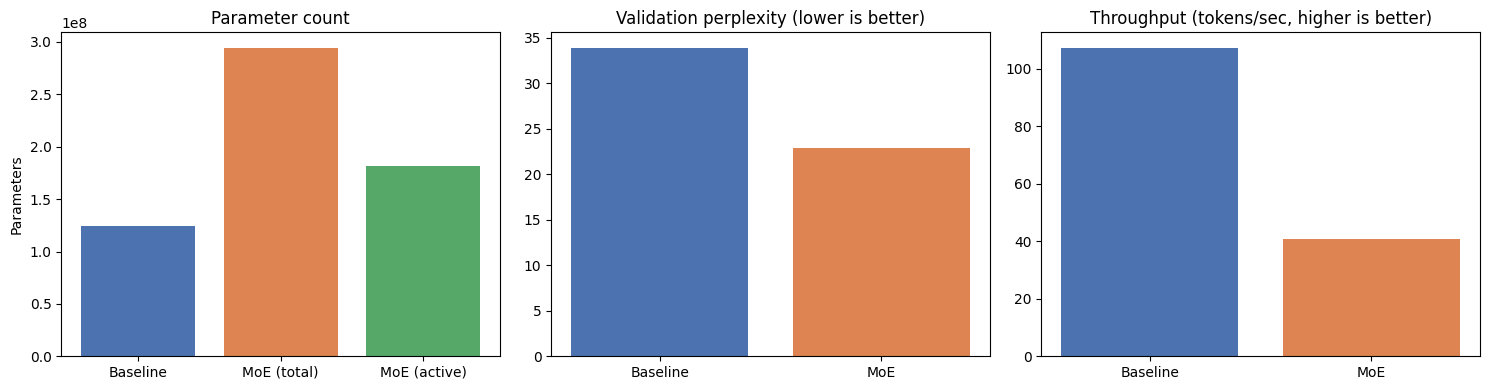

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(["Baseline", "MoE (total)", "MoE (active)"],
            [baseline_results["total_params"], moe_results["total_params"], moe_results["active_params"]],
            color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Parameter count")
axes[0].set_ylabel("Parameters")

axes[1].bar(["Baseline", "MoE"], [baseline_results["ppl"], moe_results["ppl"]],
            color=["#4C72B0", "#DD8452"])
axes[1].set_title("Validation perplexity (lower is better)")

axes[2].bar(["Baseline", "MoE"], [baseline_results["tokens_per_sec"], moe_results["tokens_per_sec"]],
            color=["#4C72B0", "#DD8452"])
axes[2].set_title("Throughput (tokens/sec, higher is better)")

plt.tight_layout()
plt.savefig("moe_comparison.png", dpi=150)
plt.show()
